#### Question 1

**ISLP, chapter 5, conceptual excercise #2, parts a, b, c, d, e, f**

**We will now derive the probability that a given observation is part of a bootstrap sample. Suppose that we obtain a bootstrap sample from a set of $n$ observations.**

**(a) What is the probability that the first bootstrap observation is not the $j$th observation from the original sample? Justify your answer.**

For the first bootstrap observation, the probability that it is the $j$th observation from the original sample is $\cfrac{1}{n}$. Therefore, the probability that the first bootstrap observation is not the $j$th observation from the original sample is $$1-\cfrac{1}{n}$$

***

**(b) What is the probability that the second bootstrap observation is not the jth observation from the original sample?**

Because the sampling process of each observation in the bootstrap is independent of others, the probability that the second bootstrap observation is not the $j$th observation from the original sample is $$1-\cfrac{1}{n}$$

***

**(c) Argue that the probability that the $j$th observation is not in the bootstrap sample is $(1− 1/n)^n$**

For each observation in the bootstrap sample, the probability that it is not the the $j$th observation in the original data is $1-\cfrac{1}{n}$. And the sampling of each observation is independent of others, the probability that the $j$th is not in the bootstrap sample is $$(1-\cfrac{1}{n})^n$$

***

**(d) When $n = 5$, what is the probability that the jth observation is in the bootstrap sample?**

The probability that $j$th observation is in the bootstrap sample is $1-(1-\cfrac{1}{n})^n$.

When $n=5$, the probability is $$1-(1-\cfrac{1}{5})^5=\cfrac{2101}{3125}=0.67232$$

***

**(e) When $n = 100$, what is the probability that the jth observation is in the bootstrap sample?**

When $n=100$, the probability is $$1-(1-\cfrac{1}{100})^{100}\approx 0.63397$$

***

**(f) When $n = 10,000$, what is the probability that the jth observation is in the bootstrap sample?**

When $n=10000$, the probability is $$1-(1-\cfrac{1}{10000})^{10000}\approx 0.63214$$

***

#### Question 2

**ISLP, chapter 5, conceptual excercise #4**

**Suppose that we use some statistical learning method to make a prediction for the response $Y$ for a particular value of the predictor $X$. Carefully describe how we might estimate the standard deviation of our prediction.**

1. For the original training set, we can do the bootstrap, and then get new *N* training datasets $S_1,\cdots,S_N$.
2. For each training datasets, we establish the model $M_i,\ i=1\cdots,N$.
3. Using $M_i$ to predict $Y^*_i$ on the new data $X$.
4. Calculating the standard deviation using $Y^*_1,\cdots,Y^*_N$,
   $$SD^*=\sqrt{\cfrac{1}{n-1}\sum_{i=1}^N{(Y^*_i-\bar{Y}^*)^2}}$$

***

#### Question 3

**In this problem, we will perform cross-validation on a simulated data set.**

**(a) Generate a simulated data set using the following code:**
```{python}
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
```
**In this data set, what is $n$ and what is $p$? Write out the model used to generate the data in equation form.**

$$
\begin{align*}
    n &= 100 \\
    p &= 1 \\
    y_i &= x_i-2x_i^2+\epsilon_i,\ \epsilon\sim N(0,1),\ x\sim N(0,1),\ i=1,\cdots,n
\end{align*}
$$

In [4]:
import numpy as np

# set the random seed
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

**(b) Create a scatterplot of $X$ against $Y$. Comment on what you find.**

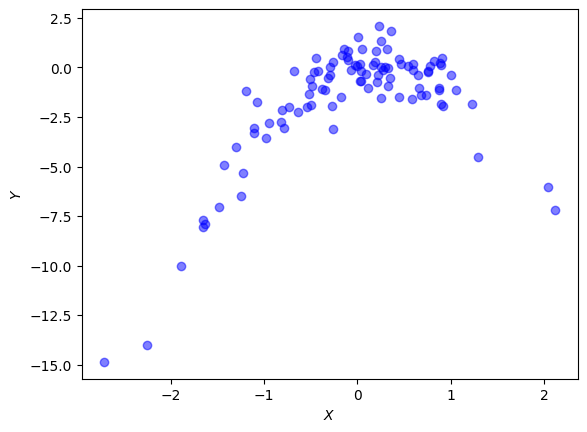

In [194]:
import matplotlib.pyplot as plt

plt.scatter(x, y, c="b", alpha=0.5)
plt.xlabel('$X$')
plt.ylabel('$Y$')
plt.show()

The relationship between $Y$ and $X$ is not linear, and maybe quadratic.

***

**(c) Construct 5 folds using `sklearn.model_selection.KFold`, and specify `random_state=3`. Using these folds, compute the cross-validation errors that result from fitting the following four models using least squares. Use the same five folds for all four models.**
$$
\begin{align*}
    1.\ Y &= \beta_0+\beta_1X+\epsilon \\
    2.\ Y &= \beta_0+\beta_1X+\beta_2X^2+\epsilon \\
    3.\ Y &= \beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon \\
    4.\ Y &= \beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\beta_4X^4+\epsilon \\
\end{align*}
$$
For each fold and each model, report the mean squared error. Which of the models had the smallest average error? Is this what you expected? Explain your answer.

In [318]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

kn = KFold(n_splits=5, random_state=3, shuffle=True)
degree = [1, 2, 3, 4]

# create the polynomiaml predictor variable
def x_poly(x, degree):
    x_poly = np.column_stack([x ** i for i in range(1, degree+1)])
    return x_poly

model_mse = {}
for i in degree:
    model = LinearRegression()
    X = x_poly(x, i)
    mse = -cross_val_score(model, X, y, cv=kn, scoring="neg_mean_squared_error", n_jobs=-1)
    model_mse[f"degree {i}"] = mse

print(f"The mean squared error for each fold and each model: \n {model_mse}")

# average mse for each model
avg_mse = {key: values.mean() for key, values in model_mse.items()}

# the model with the smallest average mse
min_key, min_value = min(avg_mse.items(), key = lambda x: x[1])
print(f"The model with {min_key} has the lowest average mse: {min_value}")


The mean squared error for each fold and each model: 
 {'degree 1': array([4.11134532, 8.25664952, 6.31059323, 5.77868275, 7.49398369]), 'degree 2': array([1.19221893, 1.03988135, 0.72603151, 0.555233  , 2.13193808]), 'degree 3': array([1.1834061 , 1.01189386, 0.80271016, 0.64246226, 2.60127317]), 'degree 4': array([1.35560527, 0.9741139 , 0.73725537, 0.55219749, 3.22659515])}
The model with degree 2 has the lowest average mse: 1.1290605755028915


The second model has the smallest mse, which matches with my expectations. Because the origianl $y$ from the quadratic function of $x$, the model with 2 degrees fits best and get lowest mse in the test data set.

***

#### Question 4

**Consider estimating log odds using logistic regression with ridge penalties, setting the regularization strength via LOOCV. True or false: the result will depend on a random seed that we use as part of the LOOCV process. Explain your answer.**

- False
  - The LOOCV process is deterministic because a different sample is strictly reserved each time the verification set is divided, and there is no randomdata segmentation.

***

#### Question 5

**ISLP, chapter 5, applied exercise #9**

In [6]:
import pandas as pd

bos = pd.read_csv("boston.csv", sep=',', index_col=0)
bos.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


**(a) Based on this data set, provide an estimate for the population mean of `medv`. Call this estimate $\hat{\mu}$.**

In [8]:
mu = bos.medv.mean()
print(f"the estimated population mean of medv: {mu}")

the estimated population mean of medv: 22.532806324110677


***

**(b) Provide an estimate of the standard error of $\hat{\mu}$. Interpret this
result.**

*Hint: We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.*

In [10]:
# the default value of ddof arg in pandas.std is 1
# the default value of ddof arg in numpy.std is 0
se = bos.medv.std() / np.sqrt(len(bos.medv))
print(f"the estimated standard error of estimated mean: {se:.4f}")

the estimated standard error of estimated mean: 0.4089


The theoretical method to calcualte the standard error is $$SE(\hat{\mu})=\cfrac{\sigma}{\sqrt{n}}$$
We usually use the sample standard deviation $s$ to estimate the population standard deviation $\sigma$. Therefore, we use $$\widehat{SE(\hat{\mu})}=\cfrac{s}{\sqrt{n}}$$

***

**(c) Now estimate the standard error of $\hat{\mu}$ using the bootstrap. How does this compare to your answer from (b)?**

In [12]:
from sklearn.utils import resample

# repeat the sampling process for 1000 times
n_iterations = 1000
bootstrap_mean = []

# bootstrap
for i in range(n_iterations):
    new_data = resample(bos.medv, replace=True)
    bootstrap_mean.append(new_data.mean())

# the default value of ddof arg in pandas.std is 1
# the default value of ddof arg in numpy.std is 0
bootstrap_se = np.std(bootstrap_mean, ddof=1)
print(f"The estimated standard error of estimated mean using bootstrap: {bootstrap_se:.4f}")

The estimated standard error of estimated mean using bootstrap: 0.4160


This answer is smaller than the answer from part(b)

***

**(d) Based on your bootstrap estimate from (c), provide a $95\%$ confidence interval for the mean of medv. Compare it to the results obtained by using `Boston['medv'].std()` and the two standard error rule (3.9).**

*Hint: You can approximate a $95\%$ confidence interval using the formula $[\hat{\mu}−2SE(\hat{\mu}),\ \hat{\mu}+ 2SE(\hat{\mu})].$*

In [25]:
# 95% CI based on bootstrap standards error
CI_l_bs = bos.medv.mean() - 2 * bootstrap_se
CI_u_bs = bos.medv.mean() + 2 * bootstrap_se
print(f"The 95% CI for the mean of medv based on bootstrap: [{CI_l_bs:.4f}, {CI_u_bs:.4f}]")

# 95% CI based on the traditional method
CI_l = bos.medv.mean() - 2 * se
CI_u = bos.medv.mean() + 2 * se
print(f"The 95% CI for the mean of medv using std(): [{CI_l:.4f}, {CI_u:.4f}]")

The 95% CI for the mean of medv based on bootstrap: [21.7007, 23.3649]
The 95% CI for the mean of medv using std(): [21.7151, 23.3505]


**(e) Based on this data set, provide an estimate, $\hat{\mu}_{med}$, for the median value of medv in the population.**

In [16]:
median_hat = bos.medv.median()
print(f"The estimated median: {median_hat}")

The estimated median: 21.2


**(f) We now would like to estimate the standard error of $\hat{\mu}_{med}$. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.**

In [18]:
n_iter = 1000
bootstrap_med = []

for i in range(n_iter):
    new_data2 = resample(bos.medv, replace=True)
    bootstrap_med.append(new_data2.median())

bootstrap_med_se = np.std(bootstrap_med, ddof=1)
print(f"The estimated standard error of the median: {bootstrap_med_se}")

The estimated standard error of the median: 0.36929096023774133


The standard error is pretty small, indicating the stability of the median estimate.

***

**(g) Based on this data set, provide an estimate for the tenth `percentile` of medv in Boston census tracts. Call this quantity $\hat{\mu}_{0.1}$. (You can use the `np.percentile()` function.)**

In [20]:
tp_hat = np.percentile(bos.medv, 10)
print(f"The estimated 10th percentile: {tp_hat}")

The estimated 10th percentile: 12.75


**(h) Use the bootstrap to estimate the standard error of $\hat{\mu}_{0.1}$. Comment on your findings.**

In [22]:
n_iter = 1000
bootstrap_tp = []

for i in range(n_iter):
    new_data3 = resample(bos.medv, replace=True)
    bootstrap_tp.append(np.percentile(new_data3, 0.1))

bootstrap_tp_se = np.std(bootstrap_tp, ddof=1)
print(f"The estimated standard error of 10th percentile: {bootstrap_tp_se}")

The estimated standard error of 10th percentile: 0.43022189081837675


As the standard error is relatively small, it indicates that using $10th$ percentile to estimate the population quantile is rather stable.

***

#### Question 6

**In this problem, we will compute the LOOCV error for a logistic regression model on the `Weekly` data set, which can be downloaded from Canvas.**

**(a) Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2`. Report and comment on the result.**

In [393]:
from sklearn.linear_model import LogisticRegression

weekly = pd.read_csv("weekly.csv", index_col=0)
X = weekly[['Lag1', 'Lag2']]
y = (weekly['Direction'] == 'Up').astype(int)

lr_model = LogisticRegression()
lr_model.fit(X,y)

# Get the coefficients and intercept
print("Model coefficients:")
print(f"Lag1: {lr_model.coef_[0][0]:.4f}")
print(f"Lag2: {lr_model.coef_[0][1]:.4f}")
print(f"Intercept: {lr_model.intercept_[0]:.4f}")

# Calculate accuracy on training data
accuracy = lr_model.score(X, y)
print(f"\nTraining accuracy: {accuracy:.4f}")

Model coefficients:
Lag1: -0.0387
Lag2: 0.0602
Intercept: 0.2212

Training accuracy: 0.5546


The accuracy of the model is 0.5546, close to 50%, which indicates that `Lag1` and `Lag2` have limited prediction ability on `Direction`.

***

**(b) Fit a logistic regression model that predicts `Direction` using `Lag1` and `Lag2` using all but the first observation. Report and comment on the result.**

In [412]:
xb = weekly.loc[1:, ['Lag1', 'Lag2']]
yb = (weekly['Direction'] == 'Up').iloc[1:].astype(int)

modelb = LogisticRegression()
modelb.fit(xb, yb)

# Get the coefficients and intercept
print("Model coefficients:")
print(f"Lag1: {modelb.coef_[0][0]:.4f}")
print(f"Lag2: {modelb.coef_[0][1]:.4f}")
print(f"Intercept: {modelb.intercept_[0]:.4f}")

# Calculate accuracy on training data
accuracyb = modelb.score(X, y)
print(f"\nTraining accuracy: {accuracyb:.4f}")

Model coefficients:
Lag1: -0.0384
Lag2: 0.0608
Intercept: 0.2232

Training accuracy: 0.5565


After kicking off the first observation, the logistic model still doesn't fit well as the accuracy rate is also around $55\%$.

***

**(c) Use the model from (b) to predict the direction of the first observation. Was this observation correctly classified?**

In [430]:
# Get the first observation's predictors
obv1 = weekly.loc[0, ['Lag1', 'Lag2']]

# Reshape as a DataFrame to maintain feature names
obv1 = pd.DataFrame([obv1], columns=['Lag1', 'Lag2'])

# Make prediction
obv1_pred = modelb.predict(obv1)

# Get actual direction for comparison
actual_direction = weekly.loc[0, 'Direction']

# Print results
print(f"Predicted direction: {'Up' if obv1_pred[0] == 1 else 'Down'}")
print(f"Actual direction: {actual_direction}")
print(f"Correctly classified: {(obv1_pred[0] == 1) == (actual_direction == 'Up')}")

Predicted direction: Up
Actual direction: Down
Correctly classified: False


**(d) Write a for loop from $i=1$ to $i=n$, where $n$ is the number of observations in the data set, that performs each of the following steps:**

- **Fit a logistic regression model using all but the ith observation to predict `Direction` using `Lag1` and `Lag2`.**
- **Use this model to predict the direction for the the $i$th observation.**
- **Determine whether or not an error was made in predicting the direction for the $i$th observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.**

In [459]:
error_list = []

for i in range(len(weekly)):
    mask = np.ones(len(weekly), dtype=bool)
    mask[i] = False

    #training data
    x = weekly.loc[mask, ['Lag1', 'Lag2']]
    y = (weekly['Direction'] == 'Up').loc[mask].astype(int)

    #validation data
    val = pd.DataFrame([weekly.loc[i, ['Lag1', 'Lag2']]], columns=['Lag1', 'Lag2'])

    # model
    model = LogisticRegression()
    model.fit(x, y)

    result = 'Up' if model.predict(val)[0] == 1 else 'Down'
    if_error = 0 if result == weekly.loc[i, 'Direction'] else 1
    error_list.append(if_error)

**(e) Take the average of the $n$ numbers obtained in part (d)3 of this problem in order to obtain the LOOCV estimate for the test error. Comment on the results.**

In [472]:
avg_error = np.array(error_list).mean()
print(f"The average error of the LOOCV estimate is: {avg_error:.4f}")

The average error of the LOOCV estimate is: 0.4500


The average error is close to 0.5, which is matched with the part (a) and part(b). The prediction accuracy of using logistic regression is not high.

***